In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pygom import Event, Transition, SimulateOde


N = 10000
R0 = 1.5
gamma = 1 / 4.0
beta = R0 * gamma

# Params and states
params=['beta', 'gamma', 'N']
states=['S', 'I', 'R']

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

transition_names = ['new_infections', 'new_recoveries']

event_list = [event_infection, event_recovery]
model = SimulateOde(state=states, param=params, event=event_list)
# model.parameters = {"beta": beta, "gamma": gamma, "N":N}



i0 = 20
y0 = np.array([N-i0, i0, 0])

ylims = [(0, N), (0, N), (0, N)]
ylims = np.asarray(ylims, dtype=object)  # because we have None
mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in ylims])
maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in ylims])
model.x_min = mins
model.x_max = maxs


prob_failure = (1/R0)**i0
print(f"Prob stochastic extinction: {prob_failure}")

model.initial_values = (y0, 0.0)


t_eval = np.arange(0, 100, 1)

Prob stochastic extinction: 0.00030072865982171717


In [3]:
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

model.ode(y0, 0)

array([-7.485,  2.485,  5.   ])

In [ ]:
from pygom import SquareLoss

t = np.linspace(0, 100, 10)
solution = model.solve_deterministic(t)[0].result.y
y = solution[1::, 1:3]

# initial value
theta = np.array([0.4, 0.2])

loss = SquareLoss(
    theta=theta,
    ode=model,
    x0=y0,
    t0=t[0],
    t=t[1::],
    y=y,
    state_name=['I', 'R'])

loss.adjoint(theta)



ValueError: The length of the supplied list of values must match the number of parameter. Expected 3, got 2.

In [ ]:
def jac(self, theta=None, sens_output=False, full_output=False, method=None):
    """
    Obtain the Jacobian of the objective function given input parameters
    using forward sensitivity method.

    Parameters
    ----------
    theta: array like, optional
        input value of the parameters
    sens_output: bool, optional
        whether the full sensitivities is required; full_output overrides this
        option when true
    full_output: bool, optional
        if additional output is required
    method: str, optional
        Choice between lsoda, vode and dopri5, the three integrator
        provided by scipy.  Defaults to lsoda.

    Returns
    -------
    grad: :class:`numpy.ndarray`
        Jacobian of the objective function
    infodict : dict, only returned if full_output=True
        Dictionary containing additional output information

        ===========  =======================================================
        key          meaning
        ===========  =======================================================
        'sens'       intermediate values over the original ode and all the
                        sensitivities, by state, parameters
        'resid'      residuals given theta
        'diff_loss'  derivative of the loss function
        ===========  =======================================================

    See also
    --------
    :meth:`sensitivity`

    """

    if theta is not None:
        self._setParam(theta)

    self._ode.parameters = self._theta

    if method is None:
        method = self._ode._intName

    # first we want to find out the number of sensitivities required
    # add them to the initial values
    num_sens =  self._num_state*self._num_param
    init_state_sens = np.append(self._x0, np.zeros(num_sens))

    f = ode_utils.integrateFuncJac

    index_out = self._getTargetParamSensIndex()

    if full_output:
        s_sens = f(self._ode.ode_and_sensitivity_T,
                    self._ode.ode_and_sensitivity_jacobian_T,
                    init_state_sens,
                    self._t[0], self._t[1::],
                    full_output=full_output,
                    method=method)
        sol_sens = s_sens[0]
        sol_out = s_sens[1]

        output = dict()
        i = self._stateIndex
        output['resid'] = self._lossObj.residual(sol_sens[:, i])
        output['diff_loss'] = self._lossObj.diff_loss(sol_sens[:, i])
        output['sens'] = sol_sens
        for i in sol_out:
            output[i] = sol_out[i]

        return sol_sens[:,index_out], output
    else:
        sol_sens = f(self._ode.ode_and_sensitivity_T,
                        self._ode.ode_and_sensitivity_jacobian_T,
                        init_state_sens,
                        self._t[0], self._t[1::],
                        method=method)

        if sens_output:
            return sol_sens[:, index_out], sol_sens
        else:
            return sol_sens[:,index_out]

TypeError: DeterministicOde.adjoint() missing 1 required positional argument: 'state_param'

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\post_processing.py:130: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  density = np.divide(event_counts[:, i], dt, where=dt>0)


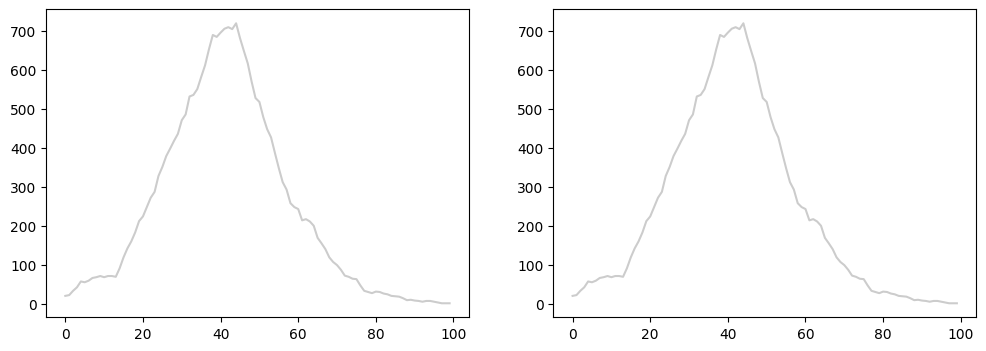

In [2]:
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

outs1 = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    perf=True,
    iteration=1,
    seed=10
)

outs2 = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    perf=True,
    iteration=1,
    seed=10
)

fig, ax = plt.subplots(1, 2, figsize = (12, 4))

for out in outs1:
    ax[0].plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
for out in outs2:
    ax[1].plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
plt.show()

In [3]:
from pygom.utilR import rgamma
random_param_set = dict()  # container for random param set
random_param_set['gamma'] = (rgamma, {'shape':100, 'rate':400})
random_param_set['beta'] = (rgamma, {'shape':100, 'rate':333.33})
random_param_set['N'] = 1e4

model.parameters=random_param_set

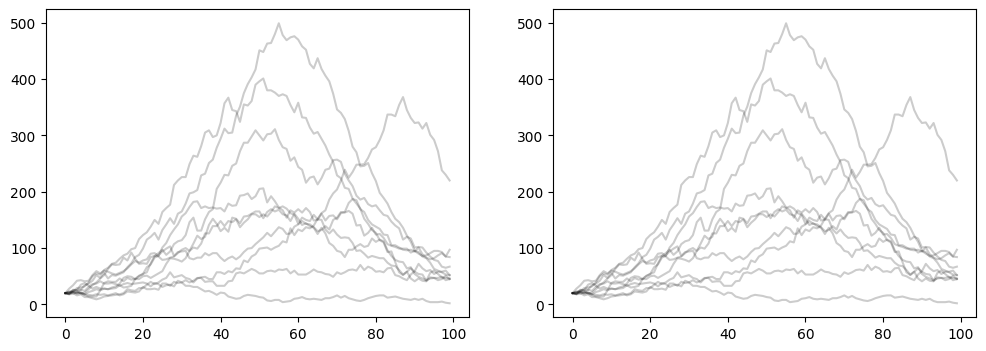

In [4]:
outs1 = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    perf=True,
    iteration=10,
    seed=1
)

outs2 = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    perf=True,
    iteration=10,
    seed=1
)

fig, ax = plt.subplots(1, 2, figsize = (12, 4))

for out in outs1:
    ax[0].plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
for out in outs2:
    ax[1].plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
plt.show()

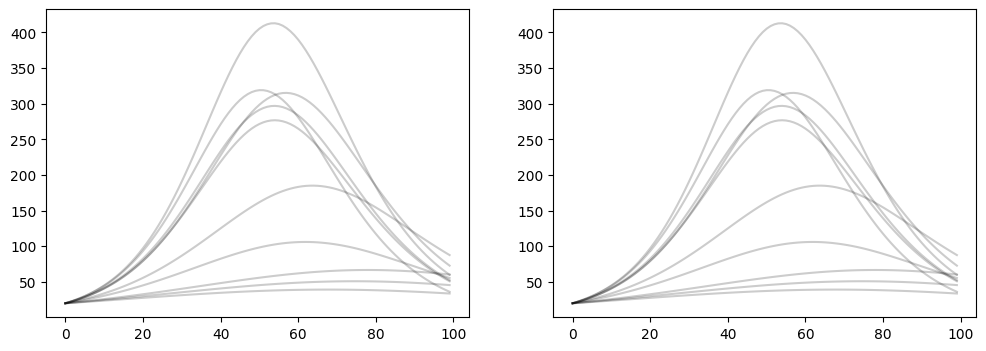

In [5]:
outs1 = model.solve_deterministic(
    t=t_eval,
    perf=True,
    iteration=10,
    seed=1
)

outs2 = model.solve_deterministic(
    t=t_eval,
    perf=True,
    iteration=10,
    seed=1
)

fig, ax = plt.subplots(1, 2, figsize = (12, 4))

for out in outs1:
    ax[0].plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
for out in outs2:
    ax[1].plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
plt.show()